In [1]:
# ============================================================
# R2_ROMA_aligned_allocation_backtest.ipynb
# ROMA-TWETF Clean Rebuild: Aligned Allocation Backtest
#
# Purpose:
# 1. Load ROMA R1 purged walk-forward regime probabilities.
# 2. Convert ROMA regime probabilities into return-seeking ETF weights.
# 3. Use the same ETF universe, transaction cost, and aligned test dates as AURORA.
# 4. Compare ROMA policies against the same strong financial baselines.
# 5. Export ROMA daily returns and weights for R3 and Notebook 13.
#
# This notebook creates:
# outputs/ROMA_TWETF/aligned_allocation_backtest/run_<RUN_ID>/
#   returns/
#   weights/
#   tables/
#   reports/
#   figures/
#   NOTEBOOK_R3_ROMA_INPUT_INDEX.csv
#
# Educational/research use only.
# Not personalized financial advice.
# ============================================================

from __future__ import annotations

import json
import math
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone

warnings.filterwarnings("ignore")

# ============================================================
# 0. Colab setup
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Google Drive mount skipped or failed.")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

# ============================================================
# 1. Paths and run configuration
# ============================================================

PROJECT_CODE = "ROMA_TWETF"
AURORA_CODE = "AURORA_TWETF"

PUBLICATION_ROOT = Path("/content/drive/MyDrive/AURORA_TWETF")

DATA_ROOT = PUBLICATION_ROOT / "data"
PANEL_DIR = DATA_ROOT / "panels"

# R1 run from your completed ROMA rebuild.
ROMA_R1_RUN_ID = "20260625_023629"

ROMA_R1_ROOT = (
    PUBLICATION_ROOT
    / "outputs"
    / PROJECT_CODE
    / "purged_walk_forward_regime_signals"
    / f"run_{ROMA_R1_RUN_ID}"
)

ROMA_R2_DEDUP_INDEX_PATH = ROMA_R1_ROOT / "NOTEBOOK_R2_ROMA_DEDUP_INPUT_INDEX.csv"

# Shared ETF return panel produced by AURORA Notebook 01/02.
ETF_RETURN_PANEL_CANDIDATES = [
    PANEL_DIR / "AURORA_etf_return_panel.parquet",
    PANEL_DIR / "AURORA_TWETF_etf_return_panel.parquet",
    PANEL_DIR / "etf_return_panel.parquet",
    PANEL_DIR / "AURORA_etf_returns.parquet",
]

# Optional AURORA Notebook 10 comparison returns, used only for metadata alignment diagnostics.
AURORA_NOTEBOOK10_RUN_ID = "20260624_100748"
AURORA_NOTEBOOK10_ROOT = (
    PUBLICATION_ROOT
    / "outputs"
    / AURORA_CODE
    / "uncertainty_aware_mean_variance_allocation"
    / f"run_{AURORA_NOTEBOOK10_RUN_ID}"
)

AURORA_COMPARISON_RETURNS_CANDIDATES = [
    AURORA_NOTEBOOK10_ROOT / "returns" / "comparison_returns_uamv_vs_benchmarks.parquet",
    AURORA_NOTEBOOK10_ROOT / "returns" / "comparison_returns_uamv_vs_benchmarks.csv",
]

OUTPUT_ROOT = PUBLICATION_ROOT / "outputs" / PROJECT_CODE
TABLE_DIR = OUTPUT_ROOT / "tables"
REPORT_DIR = OUTPUT_ROOT / "reports"
FIGURE_DIR = OUTPUT_ROOT / "figures"

RUN_TIMESTAMP = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")

RUN_ROOT = OUTPUT_ROOT / "aligned_allocation_backtest" / f"run_{RUN_ID}"

RETURN_DIR = RUN_ROOT / "returns"
WEIGHT_DIR = RUN_ROOT / "weights"
TABLE_RUN_DIR = RUN_ROOT / "tables"
REPORT_RUN_DIR = RUN_ROOT / "reports"
FIGURE_RUN_DIR = RUN_ROOT / "figures"
PAPER_FIGURE_DIR = RUN_ROOT / "paper_figures"

for d in [
    OUTPUT_ROOT,
    TABLE_DIR,
    REPORT_DIR,
    FIGURE_DIR,
    RUN_ROOT,
    RETURN_DIR,
    WEIGHT_DIR,
    TABLE_RUN_DIR,
    REPORT_RUN_DIR,
    FIGURE_RUN_DIR,
    PAPER_FIGURE_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("ROMA-TWETF R2: Aligned Allocation Backtest")
print("=" * 80)
print("Timestamp UTC       :", RUN_TIMESTAMP)
print("Run ID              :", RUN_ID)
print("ROMA R1 run ID      :", ROMA_R1_RUN_ID)
print("ROMA R1 root        :", ROMA_R1_ROOT)
print("R2 dedup index      :", ROMA_R2_DEDUP_INDEX_PATH)
print("Run root            :", RUN_ROOT)
print("=" * 80)

if not ROMA_R2_DEDUP_INDEX_PATH.exists():
    raise FileNotFoundError(f"Missing R1 dedup index: {ROMA_R2_DEDUP_INDEX_PATH}")

# ============================================================
# 2. Global settings
# ============================================================

ETF_UNIVERSE = ["0050", "006208", "00692", "00881"]
CASH_COL = "CASH"
ASSET_COLS = ETF_UNIVERSE + [CASH_COL]

CLASS_LABELS = [0, 1, 2, 3, 4]

REGIME_LABELS = {
    0: "strong_bear",
    1: "bear",
    2: "neutral",
    3: "bull",
    4: "strong_bull",
}

TARGET_20D = "TAIEX_regime_fixed_20d"
TARGET_60D = "TAIEX_regime_fixed_60d"

TRANSACTION_COST_RATE = 0.0010
REBALANCE_FREQUENCY = "monthly"
ANNUALIZATION = 252

# Final AURORA strict-test alignment is governed by common 20d/60d test probability dates.
# From R1, strict 20d = 359 rows, strict 60d = 319 rows.
# Their intersection should be 319 rows from 2024-11-27 to 2026-03-25.
EVALUATION_SPLITS = ["oos_validation_plus_test", "strict_test_only"]

RANDOM_STATE = 42

# ============================================================
# 3. Utility functions
# ============================================================

def save_json(path, obj):
    Path(path).write_text(
        json.dumps(obj, indent=2, ensure_ascii=False, default=str),
        encoding="utf-8",
    )

def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    h = hashlib.sha256()

    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)

    return h.hexdigest()

def make_file_manifest(root):
    root = Path(root)
    rows = []

    for p in sorted(root.rglob("*")):
        if p.is_file():
            stat = p.stat()
            rows.append({
                "path": p.relative_to(root).as_posix(),
                "size_bytes": int(stat.st_size),
                "modified_utc": datetime.fromtimestamp(
                    stat.st_mtime,
                    timezone.utc,
                ).strftime("%Y-%m-%dT%H:%M:%SZ"),
                "sha256": sha256_file(p),
            })

    return pd.DataFrame(rows)

def safe_name(x):
    return (
        str(x)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
        .replace(" ", "_")
        .replace(".", "_")
        .replace("%", "pct")
        .replace("-", "_")
    )

def read_table(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)

    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)

    raise ValueError(f"Unsupported file type: {path}")

def find_existing_path(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    return None

def normalize_weights(w):
    w = np.asarray(w, dtype=float)
    w = np.nan_to_num(w, nan=0.0, posinf=0.0, neginf=0.0)
    w[w < 0] = 0.0

    s = w.sum()

    if s <= 0:
        out = np.zeros_like(w)
        out[-1] = 1.0
        return out

    return w / s

def normalize_weight_df(weights):
    out = weights.copy()

    for c in ASSET_COLS:
        if c not in out.columns:
            out[c] = 0.0

    out[ASSET_COLS] = out[ASSET_COLS].fillna(0.0).clip(lower=0.0)
    row_sum = out[ASSET_COLS].sum(axis=1)

    bad = row_sum <= 0
    if bad.any():
        out.loc[bad, ETF_UNIVERSE] = 0.0
        out.loc[bad, CASH_COL] = 1.0
        row_sum = out[ASSET_COLS].sum(axis=1)

    out[ASSET_COLS] = out[ASSET_COLS].div(row_sum, axis=0)

    return out

def proba_cols():
    return [f"proba_class_{c}" for c in CLASS_LABELS]

def normalize_proba(df):
    out = df.copy()
    cols = proba_cols()

    for c in cols:
        if c not in out.columns:
            out[c] = 0.0

    p = out[cols].to_numpy(dtype=float)
    p = np.nan_to_num(p, nan=0.0, posinf=0.0, neginf=0.0)
    p[p < 0] = 0.0

    row_sum = p.sum(axis=1, keepdims=True)
    zero = row_sum[:, 0] <= 0

    if zero.any():
        p[zero, :] = 1.0 / len(cols)
        row_sum = p.sum(axis=1, keepdims=True)

    p = p / row_sum

    for j, c in enumerate(cols):
        out[c] = p[:, j]

    return out

def expected_class_from_df(df):
    p = normalize_proba(df)[proba_cols()].to_numpy(dtype=float)
    cls = np.asarray(CLASS_LABELS, dtype=float)
    return p @ cls

def entropy_from_df(df):
    p = normalize_proba(df)[proba_cols()].to_numpy(dtype=float)
    ent = -np.sum(np.clip(p, 1e-12, 1.0) * np.log(np.clip(p, 1e-12, 1.0)), axis=1)
    return ent

def ordinal_variance_from_df(df):
    p = normalize_proba(df)[proba_cols()].to_numpy(dtype=float)
    cls = np.asarray(CLASS_LABELS, dtype=float)
    mean = p @ cls
    second = p @ (cls ** 2)
    return second - mean ** 2

def add_probability_features(df):
    out = normalize_proba(df)

    p = out[proba_cols()].to_numpy(dtype=float)

    out["expected_class"] = p @ np.asarray(CLASS_LABELS, dtype=float)
    out["hard_class"] = np.asarray(CLASS_LABELS)[np.argmax(p, axis=1)]
    out["bearish_probability"] = out["proba_class_0"] + out["proba_class_1"]
    out["neutral_probability"] = out["proba_class_2"]
    out["bullish_probability"] = out["proba_class_3"] + out["proba_class_4"]

    ent = entropy_from_df(out)
    out["entropy"] = ent
    out["normalized_entropy"] = ent / np.log(len(CLASS_LABELS))
    out["confidence"] = 1.0 - out["normalized_entropy"]
    out["ordinal_variance"] = ordinal_variance_from_df(out)

    sorted_p = np.sort(p, axis=1)
    out["probability_margin"] = sorted_p[:, -1] - sorted_p[:, -2]

    return out

def to_datetime_index(df, date_col="date"):
    out = df.copy()

    if date_col in out.columns:
        out[date_col] = pd.to_datetime(out[date_col])
        out = out.set_index(date_col)
    else:
        out.index = pd.to_datetime(out.index)

    out.index.name = "date"
    out = out.sort_index()

    return out

def make_rebalance_mask(index, frequency="monthly"):
    index = pd.DatetimeIndex(index).sort_values()

    if frequency == "daily":
        return pd.Series(True, index=index)

    if frequency == "monthly":
        periods = index.to_period("M")
    elif frequency == "quarterly":
        periods = index.to_period("Q")
    elif frequency == "weekly":
        periods = index.to_period("W")
    else:
        raise ValueError(f"Unsupported rebalance frequency: {frequency}")

    is_first = pd.Series(periods, index=index).ne(pd.Series(periods, index=index).shift(1))
    is_first.iloc[0] = True

    return is_first

def calculate_drawdown(equity):
    equity = pd.Series(equity).astype(float)
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    return drawdown

def calculate_performance(return_series, policy_name, split_name, annualization=ANNUALIZATION):
    r = pd.Series(return_series).dropna().astype(float)
    r.index = pd.to_datetime(r.index)

    if len(r) == 0:
        return {
            "policy_name": policy_name,
            "split": split_name,
            "n_days": 0,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
            "total_return": np.nan,
            "annual_return": np.nan,
            "annual_volatility": np.nan,
            "sharpe": np.nan,
            "sortino": np.nan,
            "max_drawdown": np.nan,
            "calmar": np.nan,
            "final_equity": np.nan,
            "mean_daily_return": np.nan,
            "daily_volatility": np.nan,
            "positive_day_rate": np.nan,
            "worst_daily_return": np.nan,
            "best_daily_return": np.nan,
        }

    equity = (1.0 + r).cumprod()
    total_return = float(equity.iloc[-1] - 1.0)

    n = len(r)
    annual_return = float((equity.iloc[-1]) ** (annualization / n) - 1.0)

    daily_vol = float(r.std(ddof=1)) if n > 1 else np.nan
    annual_vol = float(daily_vol * np.sqrt(annualization)) if np.isfinite(daily_vol) else np.nan

    mean_daily = float(r.mean())
    sharpe = float((mean_daily / daily_vol) * np.sqrt(annualization)) if daily_vol and daily_vol > 0 else np.nan

    downside = r[r < 0]
    downside_vol = float(downside.std(ddof=1)) if len(downside) > 1 else np.nan
    sortino = float((mean_daily / downside_vol) * np.sqrt(annualization)) if np.isfinite(downside_vol) and downside_vol > 0 else np.nan

    dd = calculate_drawdown(equity)
    max_dd = float(dd.min())

    calmar = float(annual_return / abs(max_dd)) if max_dd < 0 else np.nan

    return {
        "policy_name": policy_name,
        "split": split_name,
        "n_days": int(n),
        "start_date": r.index.min(),
        "end_date": r.index.max(),
        "total_return": total_return,
        "annual_return": annual_return,
        "annual_volatility": annual_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_dd,
        "calmar": calmar,
        "final_equity": float(equity.iloc[-1]),
        "mean_daily_return": mean_daily,
        "daily_volatility": daily_vol,
        "positive_day_rate": float((r > 0).mean()),
        "worst_daily_return": float(r.min()),
        "best_daily_return": float(r.max()),
    }

def build_return_frame(policy_name, split_name, net_returns, gross_returns, costs, turnover):
    net_returns = pd.Series(net_returns).astype(float)
    gross_returns = pd.Series(gross_returns).astype(float).reindex(net_returns.index).fillna(0.0)
    costs = pd.Series(costs).astype(float).reindex(net_returns.index).fillna(0.0)
    turnover = pd.Series(turnover).astype(float).reindex(net_returns.index).fillna(0.0)

    equity = (1.0 + net_returns).cumprod()
    drawdown = calculate_drawdown(equity)

    out = pd.DataFrame({
        "date": net_returns.index,
        "policy_name": policy_name,
        "split": split_name,
        "gross_return": gross_returns.values,
        "turnover": turnover.values,
        "transaction_cost": costs.values,
        "net_return": net_returns.values,
        "equity": equity.values,
        "drawdown": drawdown.values,
    })

    return out

def backtest_weights(
    target_weights,
    etf_returns,
    policy_name,
    split_name,
    transaction_cost_rate=TRANSACTION_COST_RATE,
    rebalance_frequency=REBALANCE_FREQUENCY,
):
    weights = target_weights.copy()
    weights.index = pd.to_datetime(weights.index)
    weights = weights.sort_index()

    etf_returns = etf_returns.copy()
    etf_returns.index = pd.to_datetime(etf_returns.index)
    etf_returns = etf_returns.sort_index()

    # Align to target weight dates.
    common_dates = weights.index.intersection(etf_returns.index).sort_values()

    weights = weights.loc[common_dates].copy()
    rets = etf_returns.loc[common_dates, ETF_UNIVERSE].copy()

    weights = normalize_weight_df(weights)

    rebalance_mask = make_rebalance_mask(common_dates, rebalance_frequency)

    current_weights = pd.Series(0.0, index=ASSET_COLS)
    current_weights[CASH_COL] = 1.0

    net_returns = []
    gross_returns = []
    costs = []
    turnovers = []
    actual_weight_rows = []

    for date in common_dates:
        target_w = weights.loc[date, ASSET_COLS].astype(float)
        rebalance = bool(rebalance_mask.loc[date])

        if rebalance:
            turnover = float(np.abs(target_w - current_weights).sum())
            cost = turnover * transaction_cost_rate
            current_weights = target_w.copy()
        else:
            turnover = 0.0
            cost = 0.0

        asset_returns = pd.Series(0.0, index=ASSET_COLS)
        for etf in ETF_UNIVERSE:
            asset_returns[etf] = float(rets.loc[date, etf])
        asset_returns[CASH_COL] = 0.0

        gross_r = float((current_weights * asset_returns).sum())
        net_r = gross_r - cost

        actual_weight_rows.append({
            "date": date,
            "policy_name": policy_name,
            "split": split_name,
            "is_rebalance": rebalance,
            **{c: float(current_weights[c]) for c in ASSET_COLS},
        })

        gross_returns.append(gross_r)
        net_returns.append(net_r)
        costs.append(cost)
        turnovers.append(turnover)

        # Drift weights after returns.
        post_values = current_weights * (1.0 + asset_returns)
        if post_values.sum() > 0:
            current_weights = post_values / post_values.sum()
        else:
            current_weights[:] = 0.0
            current_weights[CASH_COL] = 1.0

    net_returns = pd.Series(net_returns, index=common_dates)
    gross_returns = pd.Series(gross_returns, index=common_dates)
    costs = pd.Series(costs, index=common_dates)
    turnovers = pd.Series(turnovers, index=common_dates)

    returns_df = build_return_frame(
        policy_name=policy_name,
        split_name=split_name,
        net_returns=net_returns,
        gross_returns=gross_returns,
        costs=costs,
        turnover=turnovers,
    )

    actual_weights_df = pd.DataFrame(actual_weight_rows)

    perf = calculate_performance(
        return_series=net_returns,
        policy_name=policy_name,
        split_name=split_name,
    )

    perf["average_turnover"] = float(turnovers.mean()) if len(turnovers) else np.nan
    perf["total_transaction_cost"] = float(costs.sum()) if len(costs) else np.nan
    perf["rebalance_count"] = int(actual_weights_df["is_rebalance"].sum()) if len(actual_weights_df) else 0
    perf["average_cash_weight"] = float(actual_weights_df[CASH_COL].mean()) if len(actual_weights_df) else np.nan
    perf["average_00881_weight"] = float(actual_weights_df["00881"].mean()) if len(actual_weights_df) else np.nan

    return returns_df, actual_weights_df, perf

def save_table(df, local_name, global_name):
    local_path = TABLE_RUN_DIR / local_name
    global_path = TABLE_DIR / global_name

    df.to_csv(local_path, index=False)
    df.to_csv(global_path, index=False)

    return local_path, global_path

# ============================================================
# 4. Load ETF returns
# ============================================================

print("\n" + "=" * 80)
print("Step 1: Loading ETF return panel")
print("=" * 80)

etf_return_path = find_existing_path(ETF_RETURN_PANEL_CANDIDATES)

if etf_return_path is None:
    raise FileNotFoundError(
        "Could not find ETF return panel. Tried:\n"
        + "\n".join(str(p) for p in ETF_RETURN_PANEL_CANDIDATES)
    )

etf_returns_raw = read_table(etf_return_path)
etf_returns = to_datetime_index(etf_returns_raw)

missing_etfs = [c for c in ETF_UNIVERSE if c not in etf_returns.columns]
if missing_etfs:
    raise ValueError(f"ETF return panel missing columns: {missing_etfs}")

etf_returns = etf_returns[ETF_UNIVERSE].copy()
etf_returns = etf_returns.apply(pd.to_numeric, errors="coerce").fillna(0.0)
etf_returns = etf_returns.sort_index()

print("ETF return panel:", etf_return_path)
print("Shape           :", etf_returns.shape)
print("Date range      :", etf_returns.index.min().date(), "to", etf_returns.index.max().date())

# ============================================================
# 5. Load ROMA R1 deduplicated probabilities
# ============================================================

print("\n" + "=" * 80)
print("Step 2: Loading ROMA R1 deduplicated probabilities")
print("=" * 80)

r1_index = pd.read_csv(ROMA_R2_DEDUP_INDEX_PATH)

required_index_cols = [
    "target_col",
    "horizon",
    "selected_model_name",
    "dedup_split",
    "probability_path_parquet",
    "probability_path_csv",
]

missing_cols = [c for c in required_index_cols if c not in r1_index.columns]
if missing_cols:
    raise ValueError(f"R1 dedup index missing columns: {missing_cols}")

print("R1 dedup index shape:", r1_index.shape)
print(r1_index.to_string(index=False))

probability_data = {}

for _, row in r1_index.iterrows():
    target_col = row["target_col"]
    horizon = int(row["horizon"])
    split_name = row["dedup_split"]

    p_path = Path(row["probability_path_parquet"])
    if not p_path.exists():
        p_path = Path(row["probability_path_csv"])

    proba = read_table(p_path)
    proba = to_datetime_index(proba)
    proba = add_probability_features(proba)

    key = (target_col, horizon, split_name)
    probability_data[key] = proba

    print(
        "Loaded:",
        key,
        "| shape:",
        proba.shape,
        "| dates:",
        proba.index.min().date(),
        "to",
        proba.index.max().date(),
    )

# ============================================================
# 6. Build common aligned evaluation dates
# ============================================================

print("\n" + "=" * 80)
print("Step 3: Building common aligned OOS and strict-test dates")
print("=" * 80)

aligned_dates = {}

for split_name in EVALUATION_SPLITS:
    p20 = probability_data[(TARGET_20D, 20, split_name)]
    p60 = probability_data[(TARGET_60D, 60, split_name)]

    common = p20.index.intersection(p60.index).intersection(etf_returns.index).sort_values()

    aligned_dates[split_name] = common

    print(
        split_name,
        "| n_dates:",
        len(common),
        "| start:",
        common.min().date() if len(common) else None,
        "| end:",
        common.max().date() if len(common) else None,
    )

date_report_rows = []
for split_name, idx in aligned_dates.items():
    date_report_rows.append({
        "split": split_name,
        "n_dates": int(len(idx)),
        "start_date": idx.min() if len(idx) else pd.NaT,
        "end_date": idx.max() if len(idx) else pd.NaT,
    })

date_report_df = pd.DataFrame(date_report_rows)

save_table(
    date_report_df,
    local_name="roma_R2_aligned_date_report.csv",
    global_name=f"table_R2_01_roma_aligned_date_report_{RUN_ID}.csv",
)

# ============================================================
# 7. Define ROMA return-seeking allocation templates
# ============================================================

print("\n" + "=" * 80)
print("Step 4: Defining ROMA return-seeking allocation policies")
print("=" * 80)

# ROMA is intentionally more return-seeking than AURORA.
# It maps expected regime probabilities to ETF/CASH weights.
# Templates are pre-defined, not optimized on test data.

ROMA_TEMPLATES = {
    "template_return_seeking": {
        0: {"0050": 0.10, "006208": 0.20, "00692": 0.20, "00881": 0.00, "CASH": 0.50},
        1: {"0050": 0.20, "006208": 0.30, "00692": 0.25, "00881": 0.05, "CASH": 0.20},
        2: {"0050": 0.30, "006208": 0.30, "00692": 0.25, "00881": 0.15, "CASH": 0.00},
        3: {"0050": 0.30, "006208": 0.25, "00692": 0.15, "00881": 0.30, "CASH": 0.00},
        4: {"0050": 0.20, "006208": 0.15, "00692": 0.10, "00881": 0.55, "CASH": 0.00},
    },
    "template_aggressive_growth": {
        0: {"0050": 0.15, "006208": 0.15, "00692": 0.20, "00881": 0.00, "CASH": 0.50},
        1: {"0050": 0.20, "006208": 0.25, "00692": 0.25, "00881": 0.10, "CASH": 0.20},
        2: {"0050": 0.25, "006208": 0.25, "00692": 0.20, "00881": 0.30, "CASH": 0.00},
        3: {"0050": 0.25, "006208": 0.20, "00692": 0.10, "00881": 0.45, "CASH": 0.00},
        4: {"0050": 0.15, "006208": 0.10, "00692": 0.05, "00881": 0.70, "CASH": 0.00},
    },
    "template_balanced_regime": {
        0: {"0050": 0.15, "006208": 0.25, "00692": 0.25, "00881": 0.00, "CASH": 0.35},
        1: {"0050": 0.25, "006208": 0.30, "00692": 0.30, "00881": 0.05, "CASH": 0.10},
        2: {"0050": 0.30, "006208": 0.30, "00692": 0.25, "00881": 0.15, "CASH": 0.00},
        3: {"0050": 0.30, "006208": 0.25, "00692": 0.20, "00881": 0.25, "CASH": 0.00},
        4: {"0050": 0.25, "006208": 0.20, "00692": 0.15, "00881": 0.40, "CASH": 0.00},
    },
    "template_conservative_return": {
        0: {"0050": 0.10, "006208": 0.25, "00692": 0.25, "00881": 0.00, "CASH": 0.40},
        1: {"0050": 0.25, "006208": 0.30, "00692": 0.30, "00881": 0.00, "CASH": 0.15},
        2: {"0050": 0.35, "006208": 0.30, "00692": 0.25, "00881": 0.10, "CASH": 0.00},
        3: {"0050": 0.35, "006208": 0.25, "00692": 0.20, "00881": 0.20, "CASH": 0.00},
        4: {"0050": 0.30, "006208": 0.20, "00692": 0.15, "00881": 0.35, "CASH": 0.00},
    },
}

ROMA_POLICY_CONFIGS = {
    "ROMA_P0_validation_selected_20_60_blend": {
        "description": "Validation-selected ROMA ensemble with 50/50 blend of 20d and 60d probabilities.",
        "template": "template_return_seeking",
        "alpha_20d": 0.50,
        "alpha_60d": 0.50,
        "max_etf_weight": 0.70,
        "max_00881_weight": 0.60,
        "max_cash_weight": 0.60,
        "confidence_cash_control": True,
        "uncertainty_cash_boost_max": 0.10,
        "bearish_cash_boost_max": 0.15,
    },
    "ROMA_P1_more20_return_seeking": {
        "description": "Return-seeking ROMA with stronger reliance on 20d signal because R1 showed stronger 20d diagnostics.",
        "template": "template_return_seeking",
        "alpha_20d": 0.70,
        "alpha_60d": 0.30,
        "max_etf_weight": 0.70,
        "max_00881_weight": 0.60,
        "max_cash_weight": 0.55,
        "confidence_cash_control": True,
        "uncertainty_cash_boost_max": 0.08,
        "bearish_cash_boost_max": 0.12,
    },
    "ROMA_P2_20d_only_return_seeking": {
        "description": "20d-only ROMA return-seeking policy; included because 20d R1 signal was stronger than 60d signal.",
        "template": "template_aggressive_growth",
        "alpha_20d": 1.00,
        "alpha_60d": 0.00,
        "max_etf_weight": 0.75,
        "max_00881_weight": 0.70,
        "max_cash_weight": 0.55,
        "confidence_cash_control": True,
        "uncertainty_cash_boost_max": 0.05,
        "bearish_cash_boost_max": 0.10,
    },
    "ROMA_P3_conservative_blend": {
        "description": "Conservative ROMA blend using balanced regime template and stronger cash control.",
        "template": "template_conservative_return",
        "alpha_20d": 0.60,
        "alpha_60d": 0.40,
        "max_etf_weight": 0.55,
        "max_00881_weight": 0.35,
        "max_cash_weight": 0.65,
        "confidence_cash_control": True,
        "uncertainty_cash_boost_max": 0.15,
        "bearish_cash_boost_max": 0.20,
    },
    "ROMA_P4_balanced_regime_blend": {
        "description": "Balanced regime ROMA template, close to the original hand-crafted AURORA-style mapping but more return-oriented.",
        "template": "template_balanced_regime",
        "alpha_20d": 0.60,
        "alpha_60d": 0.40,
        "max_etf_weight": 0.60,
        "max_00881_weight": 0.45,
        "max_cash_weight": 0.55,
        "confidence_cash_control": True,
        "uncertainty_cash_boost_max": 0.10,
        "bearish_cash_boost_max": 0.15,
    },
}

def validate_template(template):
    rows = []

    for cls, weights in template.items():
        w = np.array([weights.get(a, 0.0) for a in ASSET_COLS], dtype=float)
        w = normalize_weights(w)
        rows.append({
            "class": cls,
            "regime_label": REGIME_LABELS.get(cls, str(cls)),
            **{a: float(w[i]) for i, a in enumerate(ASSET_COLS)},
            "sum_weight": float(w.sum()),
        })

    return pd.DataFrame(rows)

template_rows = []
for template_name, template in ROMA_TEMPLATES.items():
    tmp = validate_template(template)
    tmp.insert(0, "template_name", template_name)
    template_rows.append(tmp)

template_df = pd.concat(template_rows, axis=0, ignore_index=True)

policy_description_df = pd.DataFrame([
    {
        "policy_name": policy_name,
        **cfg,
    }
    for policy_name, cfg in ROMA_POLICY_CONFIGS.items()
])

save_table(
    template_df,
    local_name="roma_R2_regime_templates.csv",
    global_name=f"table_R2_02_roma_regime_templates_{RUN_ID}.csv",
)

save_table(
    policy_description_df,
    local_name="roma_R2_policy_descriptions.csv",
    global_name=f"table_R2_03_roma_policy_descriptions_{RUN_ID}.csv",
)

print("ROMA policy descriptions:")
print(policy_description_df.to_string(index=False))

# ============================================================
# 8. ROMA probability-to-weight conversion
# ============================================================

print("\n" + "=" * 80)
print("Step 5: Building ROMA policy signal weights")
print("=" * 80)

def template_matrix(template_name):
    template = ROMA_TEMPLATES[template_name]
    mat = []

    for cls in CLASS_LABELS:
        weights = template[cls]
        w = np.array([weights.get(a, 0.0) for a in ASSET_COLS], dtype=float)
        w = normalize_weights(w)
        mat.append(w)

    return np.vstack(mat)

def apply_weight_caps(w, max_etf_weight, max_00881_weight, max_cash_weight, max_iter=25):
    w = pd.Series(normalize_weights(w), index=ASSET_COLS)

    for _ in range(max_iter):
        before = w.copy()

        for etf in ETF_UNIVERSE:
            if w[etf] > max_etf_weight:
                excess = w[etf] - max_etf_weight
                w[etf] = max_etf_weight
                w[CASH_COL] += excess

        if w["00881"] > max_00881_weight:
            excess = w["00881"] - max_00881_weight
            w["00881"] = max_00881_weight
            w[CASH_COL] += excess

        if w[CASH_COL] > max_cash_weight:
            excess = w[CASH_COL] - max_cash_weight
            w[CASH_COL] = max_cash_weight

            eligible = [a for a in ETF_UNIVERSE if w[a] < max_etf_weight]
            if eligible:
                current = w[eligible].copy()
                capacity = pd.Series({a: max_etf_weight - w[a] for a in eligible})
                if capacity.sum() > 0:
                    add = excess * capacity / capacity.sum()
                    for a in eligible:
                        w[a] += add[a]

        w = pd.Series(normalize_weights(w.values), index=ASSET_COLS)

        if np.max(np.abs(w.values - before.values)) < 1e-10:
            break

    return w

def build_roma_signal_weights(policy_name, cfg, proba20, proba60, split_name):
    common = proba20.index.intersection(proba60.index).sort_values()

    p20 = normalize_proba(proba20.loc[common])
    p60 = normalize_proba(proba60.loc[common])

    alpha20 = float(cfg["alpha_20d"])
    alpha60 = float(cfg["alpha_60d"])
    total_alpha = alpha20 + alpha60

    if total_alpha <= 0:
        alpha20 = 1.0
        alpha60 = 0.0
        total_alpha = 1.0

    alpha20 = alpha20 / total_alpha
    alpha60 = alpha60 / total_alpha

    p_blend = alpha20 * p20[proba_cols()].to_numpy(dtype=float) + alpha60 * p60[proba_cols()].to_numpy(dtype=float)
    p_blend = np.nan_to_num(p_blend, nan=0.0, posinf=0.0, neginf=0.0)
    p_blend[p_blend < 0] = 0.0
    row_sum = p_blend.sum(axis=1, keepdims=True)
    zero = row_sum[:, 0] <= 0

    if zero.any():
        p_blend[zero, :] = 1.0 / len(CLASS_LABELS)
        row_sum = p_blend.sum(axis=1, keepdims=True)

    p_blend = p_blend / row_sum

    mat = template_matrix(cfg["template"])

    base_weights = p_blend @ mat

    blended_proba_df = pd.DataFrame(
        p_blend,
        index=common,
        columns=proba_cols(),
    )
    blended_proba_df = add_probability_features(blended_proba_df)

    weight_rows = []
    component_rows = []

    for i, date in enumerate(common):
        w = pd.Series(base_weights[i], index=ASSET_COLS).astype(float)

        bearish = float(blended_proba_df.loc[date, "bearish_probability"])
        uncertainty = float(blended_proba_df.loc[date, "normalized_entropy"])
        confidence = float(blended_proba_df.loc[date, "confidence"])
        expected_class = float(blended_proba_df.loc[date, "expected_class"])
        hard_class = int(blended_proba_df.loc[date, "hard_class"])

        uncertainty_cash_boost = 0.0
        bearish_cash_boost = 0.0

        if cfg.get("confidence_cash_control", True):
            uncertainty_cash_boost = float(cfg["uncertainty_cash_boost_max"]) * uncertainty
            bearish_cash_boost = float(cfg["bearish_cash_boost_max"]) * bearish

            cash_boost = uncertainty_cash_boost + bearish_cash_boost

            if cash_boost > 0:
                etf_total = float(w[ETF_UNIVERSE].sum())
                reduce_amount = min(cash_boost, etf_total)

                if etf_total > 0:
                    w[ETF_UNIVERSE] = w[ETF_UNIVERSE] * (1.0 - reduce_amount / etf_total)
                    w[CASH_COL] += reduce_amount

        w = apply_weight_caps(
            w=w.values,
            max_etf_weight=float(cfg["max_etf_weight"]),
            max_00881_weight=float(cfg["max_00881_weight"]),
            max_cash_weight=float(cfg["max_cash_weight"]),
        )

        weight_rows.append({
            "date": date,
            "policy_name": policy_name,
            "split": split_name,
            **{a: float(w[a]) for a in ASSET_COLS},
        })

        component_rows.append({
            "date": date,
            "policy_name": policy_name,
            "split": split_name,
            "alpha_20d": alpha20,
            "alpha_60d": alpha60,
            "template": cfg["template"],
            "expected_class": expected_class,
            "hard_class": hard_class,
            "bearish_probability": bearish,
            "bullish_probability": float(blended_proba_df.loc[date, "bullish_probability"]),
            "neutral_probability": float(blended_proba_df.loc[date, "neutral_probability"]),
            "normalized_entropy": uncertainty,
            "confidence": confidence,
            "ordinal_variance": float(blended_proba_df.loc[date, "ordinal_variance"]),
            "probability_margin": float(blended_proba_df.loc[date, "probability_margin"]),
            "uncertainty_cash_boost": uncertainty_cash_boost,
            "bearish_cash_boost": bearish_cash_boost,
        })

    weights_df = pd.DataFrame(weight_rows)
    components_df = pd.DataFrame(component_rows)

    weights_df["date"] = pd.to_datetime(weights_df["date"])
    components_df["date"] = pd.to_datetime(components_df["date"])

    weights_df = weights_df.set_index("date").sort_index()
    components_df = components_df.set_index("date").sort_index()

    weights_df = normalize_weight_df(weights_df)

    return weights_df, components_df

# ============================================================
# 9. Define benchmark weights
# ============================================================

print("\n" + "=" * 80)
print("Step 6: Defining strong financial baselines")
print("=" * 80)

def static_weights(index, policy_name, weights_dict):
    rows = []

    for date in index:
        w = {a: 0.0 for a in ASSET_COLS}
        for k, v in weights_dict.items():
            w[k] = float(v)

        w_arr = normalize_weights([w[a] for a in ASSET_COLS])
        row = {
            "date": date,
            "policy_name": policy_name,
            "split": None,
            **{a: float(w_arr[i]) for i, a in enumerate(ASSET_COLS)},
        }
        rows.append(row)

    out = pd.DataFrame(rows)
    out["date"] = pd.to_datetime(out["date"])
    out = out.set_index("date").sort_index()

    return out

def momentum_top_k_weights(index, etf_returns, policy_name, lookback=63, top_k=1, cash_weight=0.0):
    rows = []

    cumulative = (1.0 + etf_returns[ETF_UNIVERSE]).rolling(lookback).apply(np.prod, raw=True) - 1.0

    for date in index:
        w = pd.Series(0.0, index=ASSET_COLS)

        if date not in cumulative.index:
            w[ETF_UNIVERSE] = 1.0 / len(ETF_UNIVERSE)
        else:
            mom = cumulative.loc[date, ETF_UNIVERSE].dropna()

            if len(mom) == 0:
                w[ETF_UNIVERSE] = 1.0 / len(ETF_UNIVERSE)
            else:
                selected = mom.sort_values(ascending=False).head(top_k).index.tolist()
                risky_weight = 1.0 - cash_weight
                for etf in selected:
                    w[etf] = risky_weight / len(selected)
                w[CASH_COL] = cash_weight

        w = pd.Series(normalize_weights(w.values), index=ASSET_COLS)
        rows.append({
            "date": date,
            "policy_name": policy_name,
            "split": None,
            **{a: float(w[a]) for a in ASSET_COLS},
        })

    out = pd.DataFrame(rows)
    out["date"] = pd.to_datetime(out["date"])
    out = out.set_index("date").sort_index()
    return out

def inverse_vol_weights(index, etf_returns, policy_name, lookback=63, cash_weight=0.0):
    rows = []
    vol = etf_returns[ETF_UNIVERSE].rolling(lookback).std()

    for date in index:
        w = pd.Series(0.0, index=ASSET_COLS)

        if date in vol.index:
            v = vol.loc[date, ETF_UNIVERSE].replace(0, np.nan).dropna()
        else:
            v = pd.Series(dtype=float)

        if len(v) == 0:
            w[ETF_UNIVERSE] = (1.0 - cash_weight) / len(ETF_UNIVERSE)
        else:
            inv = 1.0 / v
            inv = inv / inv.sum()
            for etf in inv.index:
                w[etf] = float(inv[etf]) * (1.0 - cash_weight)

        w[CASH_COL] = cash_weight
        w = pd.Series(normalize_weights(w.values), index=ASSET_COLS)

        rows.append({
            "date": date,
            "policy_name": policy_name,
            "split": None,
            **{a: float(w[a]) for a in ASSET_COLS},
        })

    out = pd.DataFrame(rows)
    out["date"] = pd.to_datetime(out["date"])
    out = out.set_index("date").sort_index()
    return out

def min_variance_weights(index, etf_returns, policy_name, lookback=126):
    rows = []

    for date in index:
        hist = etf_returns.loc[:date, ETF_UNIVERSE].tail(lookback)

        w = pd.Series(0.0, index=ASSET_COLS)

        if len(hist) < 20:
            w[ETF_UNIVERSE] = 1.0 / len(ETF_UNIVERSE)
        else:
            cov = hist.cov().values
            cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)
            cov = cov + np.eye(len(ETF_UNIVERSE)) * 1e-6

            try:
                inv_cov = np.linalg.pinv(cov)
                ones = np.ones(len(ETF_UNIVERSE))
                raw = inv_cov @ ones
                raw = np.maximum(raw, 0.0)

                if raw.sum() <= 0:
                    raw = np.ones(len(ETF_UNIVERSE)) / len(ETF_UNIVERSE)
                else:
                    raw = raw / raw.sum()

                for i, etf in enumerate(ETF_UNIVERSE):
                    w[etf] = float(raw[i])
            except Exception:
                w[ETF_UNIVERSE] = 1.0 / len(ETF_UNIVERSE)

        w = pd.Series(normalize_weights(w.values), index=ASSET_COLS)

        rows.append({
            "date": date,
            "policy_name": policy_name,
            "split": None,
            **{a: float(w[a]) for a in ASSET_COLS},
        })

    out = pd.DataFrame(rows)
    out["date"] = pd.to_datetime(out["date"])
    out = out.set_index("date").sort_index()
    return out

def moving_average_timing_weights(index, etf_returns, policy_name, lookback=126, base="equal"):
    rows = []
    price_proxy = (1.0 + etf_returns[ETF_UNIVERSE]).cumprod()
    ma = price_proxy.rolling(lookback).mean()

    for date in index:
        w = pd.Series(0.0, index=ASSET_COLS)

        if date not in price_proxy.index or date not in ma.index:
            w[ETF_UNIVERSE] = 1.0 / len(ETF_UNIVERSE)
        else:
            signal = price_proxy.loc[date, ETF_UNIVERSE] > ma.loc[date, ETF_UNIVERSE]
            active = signal[signal].index.tolist()

            if len(active) == 0:
                w[CASH_COL] = 1.0
            else:
                for etf in active:
                    w[etf] = 1.0 / len(active)

        w = pd.Series(normalize_weights(w.values), index=ASSET_COLS)

        rows.append({
            "date": date,
            "policy_name": policy_name,
            "split": None,
            **{a: float(w[a]) for a in ASSET_COLS},
        })

    out = pd.DataFrame(rows)
    out["date"] = pd.to_datetime(out["date"])
    out = out.set_index("date").sort_index()
    return out

def build_benchmark_weights(index, etf_returns):
    bench = {}

    bench["B1_equal_weight_all_etfs"] = static_weights(
        index,
        "B1_equal_weight_all_etfs",
        {"0050": 0.25, "006208": 0.25, "00692": 0.25, "00881": 0.25, "CASH": 0.0},
    )

    bench["B2_equal_weight_constrained"] = static_weights(
        index,
        "B2_equal_weight_constrained",
        {"0050": 0.30, "006208": 0.30, "00692": 0.25, "00881": 0.15, "CASH": 0.0},
    )

    bench["B3_0050_only"] = static_weights(
        index,
        "B3_0050_only",
        {"0050": 1.0},
    )

    bench["B4_006208_only"] = static_weights(
        index,
        "B4_006208_only",
        {"006208": 1.0},
    )

    bench["B5_00692_only"] = static_weights(
        index,
        "B5_00692_only",
        {"00692": 1.0},
    )

    bench["B6_00881_only"] = static_weights(
        index,
        "B6_00881_only",
        {"00881": 1.0},
    )

    bench["B7_equal_weight_60_40_cash"] = static_weights(
        index,
        "B7_equal_weight_60_40_cash",
        {"0050": 0.15, "006208": 0.15, "00692": 0.15, "00881": 0.15, "CASH": 0.40},
    )

    bench["B8_constrained_80_20_cash"] = static_weights(
        index,
        "B8_constrained_80_20_cash",
        {"0050": 0.24, "006208": 0.24, "00692": 0.20, "00881": 0.12, "CASH": 0.20},
    )

    bench["B9_momentum_top1_63d"] = momentum_top_k_weights(
        index,
        etf_returns,
        "B9_momentum_top1_63d",
        lookback=63,
        top_k=1,
        cash_weight=0.0,
    )

    bench["B10_momentum_top2_63d"] = momentum_top_k_weights(
        index,
        etf_returns,
        "B10_momentum_top2_63d",
        lookback=63,
        top_k=2,
        cash_weight=0.0,
    )

    bench["B11_momentum_top1_63d_20pct_cash"] = momentum_top_k_weights(
        index,
        etf_returns,
        "B11_momentum_top1_63d_20pct_cash",
        lookback=63,
        top_k=1,
        cash_weight=0.20,
    )

    bench["B12_ma_timing_equal_weight"] = moving_average_timing_weights(
        index,
        etf_returns,
        "B12_ma_timing_equal_weight",
        lookback=126,
    )

    bench["B13_inverse_volatility_63d"] = inverse_vol_weights(
        index,
        etf_returns,
        "B13_inverse_volatility_63d",
        lookback=63,
        cash_weight=0.0,
    )

    bench["B14_inverse_volatility_63d_20pct_cash"] = inverse_vol_weights(
        index,
        etf_returns,
        "B14_inverse_volatility_63d_20pct_cash",
        lookback=63,
        cash_weight=0.20,
    )

    bench["B15_minimum_variance_126d"] = min_variance_weights(
        index,
        etf_returns,
        "B15_minimum_variance_126d",
        lookback=126,
    )

    return bench

# ============================================================
# 10. Run ROMA policies and benchmarks
# ============================================================

print("\n" + "=" * 80)
print("Step 7: Running ROMA policies and benchmark backtests")
print("=" * 80)

all_return_frames = []
all_weight_frames = []
all_component_frames = []
all_performance_rows = []

for split_name in EVALUATION_SPLITS:
    print("\n" + "#" * 80)
    print("Evaluation split:", split_name)
    print("#" * 80)

    dates = aligned_dates[split_name]

    if len(dates) == 0:
        print("No dates. Skipping:", split_name)
        continue

    p20 = probability_data[(TARGET_20D, 20, split_name)].loc[dates]
    p60 = probability_data[(TARGET_60D, 60, split_name)].loc[dates]

    # ROMA policies.
    for policy_name, cfg in ROMA_POLICY_CONFIGS.items():
        print("Running ROMA policy:", policy_name)

        target_weights, components = build_roma_signal_weights(
            policy_name=policy_name,
            cfg=cfg,
            proba20=p20,
            proba60=p60,
            split_name=split_name,
        )

        returns_df, actual_weights_df, perf = backtest_weights(
            target_weights=target_weights,
            etf_returns=etf_returns,
            policy_name=policy_name,
            split_name=split_name,
            transaction_cost_rate=TRANSACTION_COST_RATE,
            rebalance_frequency=REBALANCE_FREQUENCY,
        )

        perf["policy_group"] = "ROMA_return_seeking"
        perf["policy_description"] = cfg["description"]
        perf["template"] = cfg["template"]
        perf["alpha_20d"] = cfg["alpha_20d"]
        perf["alpha_60d"] = cfg["alpha_60d"]

        all_return_frames.append(returns_df)
        all_weight_frames.append(actual_weights_df)
        all_component_frames.append(components.reset_index())
        all_performance_rows.append(perf)

    # Benchmarks on exactly the same dates.
    benchmark_weights = build_benchmark_weights(dates, etf_returns)

    for policy_name, weights in benchmark_weights.items():
        print("Running benchmark:", policy_name)

        weights = weights.copy()
        weights["split"] = split_name

        returns_df, actual_weights_df, perf = backtest_weights(
            target_weights=weights,
            etf_returns=etf_returns,
            policy_name=policy_name,
            split_name=split_name,
            transaction_cost_rate=TRANSACTION_COST_RATE,
            rebalance_frequency=REBALANCE_FREQUENCY,
        )

        perf["policy_group"] = "benchmark"
        perf["policy_description"] = "Strong passive or dynamic financial baseline."
        perf["template"] = None
        perf["alpha_20d"] = np.nan
        perf["alpha_60d"] = np.nan

        all_return_frames.append(returns_df)
        all_weight_frames.append(actual_weights_df)
        all_performance_rows.append(perf)

all_returns_df = pd.concat(all_return_frames, axis=0, ignore_index=True)
all_weights_df = pd.concat(all_weight_frames, axis=0, ignore_index=True)
all_components_df = pd.concat(all_component_frames, axis=0, ignore_index=True)
performance_df = pd.DataFrame(all_performance_rows)

for col in ["date", "start_date", "end_date"]:
    if col in all_returns_df.columns:
        all_returns_df[col] = pd.to_datetime(all_returns_df[col])
    if col in all_weights_df.columns:
        all_weights_df[col] = pd.to_datetime(all_weights_df[col])
    if col in performance_df.columns:
        performance_df[col] = pd.to_datetime(performance_df[col])

print("All returns shape     :", all_returns_df.shape)
print("All weights shape     :", all_weights_df.shape)
print("All components shape  :", all_components_df.shape)
print("Performance shape     :", performance_df.shape)

# ============================================================
# 11. Build rankings
# ============================================================

print("\n" + "=" * 80)
print("Step 8: Building ROMA rankings")
print("=" * 80)

def build_ranking(performance, split_name):
    g = performance[performance["split"] == split_name].copy()

    if g.empty:
        return g

    # Higher is better: total return, annual return, Sharpe, Sortino, Calmar.
    # Lower is better: volatility, drawdown magnitude.
    g["rank_total_return"] = g["total_return"].rank(ascending=False, method="min")
    g["rank_annual_return"] = g["annual_return"].rank(ascending=False, method="min")
    g["rank_sharpe"] = g["sharpe"].rank(ascending=False, method="min")
    g["rank_sortino"] = g["sortino"].rank(ascending=False, method="min")
    g["rank_max_drawdown"] = g["max_drawdown"].rank(ascending=False, method="min")
    g["rank_calmar"] = g["calmar"].rank(ascending=False, method="min")

    g["composite_rank"] = (
        g["rank_total_return"]
        + g["rank_annual_return"]
        + g["rank_sharpe"]
        + g["rank_sortino"]
        + g["rank_max_drawdown"]
        + g["rank_calmar"]
    ) / 6.0

    g = g.sort_values(
        ["composite_rank", "sharpe", "total_return", "max_drawdown"],
        ascending=[True, False, False, False],
    )

    return g

ranking_frames = []

for split_name in EVALUATION_SPLITS:
    ranking_frames.append(build_ranking(performance_df, split_name))

ranking_df = pd.concat(ranking_frames, axis=0, ignore_index=True)

print("Ranking summary:")
print(
    ranking_df[
        [
            "split",
            "policy_name",
            "policy_group",
            "n_days",
            "total_return",
            "annual_return",
            "annual_volatility",
            "sharpe",
            "sortino",
            "max_drawdown",
            "calmar",
            "composite_rank",
        ]
    ].to_string(index=False)
)

# ============================================================
# 12. ROMA versus best benchmark
# ============================================================

print("\n" + "=" * 80)
print("Step 9: ROMA versus best benchmark")
print("=" * 80)

comparison_rows = []

for split_name in EVALUATION_SPLITS:
    split_rank = ranking_df[ranking_df["split"] == split_name].copy()

    roma_rank = split_rank[split_rank["policy_group"] == "ROMA_return_seeking"].copy()
    benchmark_rank = split_rank[split_rank["policy_group"] == "benchmark"].copy()

    if roma_rank.empty or benchmark_rank.empty:
        continue

    best_roma = roma_rank.sort_values("composite_rank").iloc[0]
    best_benchmark = benchmark_rank.sort_values("composite_rank").iloc[0]

    for roma_policy in roma_rank["policy_name"].tolist():
        rp = split_rank[split_rank["policy_name"] == roma_policy].iloc[0]
        bp = best_benchmark

        comparison_rows.append({
            "split": split_name,
            "roma_policy_name": roma_policy,
            "best_roma_by_composite_rank": best_roma["policy_name"],
            "best_benchmark_by_composite_rank": bp["policy_name"],
            "roma_total_return": rp["total_return"],
            "benchmark_total_return": bp["total_return"],
            "excess_total_return": rp["total_return"] - bp["total_return"],
            "roma_annual_return": rp["annual_return"],
            "benchmark_annual_return": bp["annual_return"],
            "excess_annual_return": rp["annual_return"] - bp["annual_return"],
            "roma_sharpe": rp["sharpe"],
            "benchmark_sharpe": bp["sharpe"],
            "excess_sharpe": rp["sharpe"] - bp["sharpe"],
            "roma_sortino": rp["sortino"],
            "benchmark_sortino": bp["sortino"],
            "excess_sortino": rp["sortino"] - bp["sortino"],
            "roma_max_drawdown": rp["max_drawdown"],
            "benchmark_max_drawdown": bp["max_drawdown"],
            "drawdown_improvement": rp["max_drawdown"] - bp["max_drawdown"],
            "roma_calmar": rp["calmar"],
            "benchmark_calmar": bp["calmar"],
            "excess_calmar": rp["calmar"] - bp["calmar"],
            "roma_composite_rank": rp["composite_rank"],
            "benchmark_composite_rank": bp["composite_rank"],
            "rank_improvement": bp["composite_rank"] - rp["composite_rank"],
        })

comparison_df = pd.DataFrame(comparison_rows)

print("ROMA vs best benchmark:")
print(comparison_df.to_string(index=False))

# ============================================================
# 13. Optional comparison with AURORA Notebook 10 policy names
# ============================================================

print("\n" + "=" * 80)
print("Step 10: Optional AURORA comparison metadata")
print("=" * 80)

aurora_comparison_path = find_existing_path(AURORA_COMPARISON_RETURNS_CANDIDATES)

aurora_metadata_rows = []

if aurora_comparison_path is not None:
    try:
        aurora_returns = read_table(aurora_comparison_path)

        if "date" in aurora_returns.columns:
            aurora_returns["date"] = pd.to_datetime(aurora_returns["date"])

        aurora_policy_names = sorted(aurora_returns["policy_name"].dropna().unique().tolist())

        aurora_metadata_rows.append({
            "aurora_comparison_returns_path": str(aurora_comparison_path),
            "n_rows": int(len(aurora_returns)),
            "n_policies": int(len(aurora_policy_names)),
            "date_start": aurora_returns["date"].min() if "date" in aurora_returns.columns else pd.NaT,
            "date_end": aurora_returns["date"].max() if "date" in aurora_returns.columns else pd.NaT,
            "contains_AURORA10_UAMV_B": "AURORA10_UAMV_B_more60_defensive" in aurora_policy_names,
            "note": (
                "AURORA returns are not merged in R2. "
                "Unified ROMA-AURORA comparison will be performed in Notebook 13."
            ),
        })

        print("Found AURORA comparison returns:", aurora_comparison_path)
        print("AURORA policies:", aurora_policy_names[:10], "...")
    except Exception as e:
        print("Could not read AURORA comparison returns:", repr(e))
else:
    print("AURORA comparison returns not found. This is okay; Notebook 13 can load them later.")

aurora_metadata_df = pd.DataFrame(aurora_metadata_rows)

if len(aurora_metadata_df):
    save_table(
        aurora_metadata_df,
        local_name="roma_R2_aurora_metadata.csv",
        global_name=f"table_R2_06_roma_aurora_metadata_{RUN_ID}.csv",
    )

# ============================================================
# 14. Save outputs
# ============================================================

print("\n" + "=" * 80)
print("Step 11: Saving R2 outputs")
print("=" * 80)

# Returns and weights.
all_returns_parquet = RETURN_DIR / "roma_R2_all_returns.parquet"
all_returns_csv = RETURN_DIR / "roma_R2_all_returns.csv"

all_weights_parquet = WEIGHT_DIR / "roma_R2_all_weights.parquet"
all_weights_csv = WEIGHT_DIR / "roma_R2_all_weights.csv"

all_components_parquet = WEIGHT_DIR / "roma_R2_policy_components.parquet"
all_components_csv = WEIGHT_DIR / "roma_R2_policy_components.csv"

all_returns_df.to_parquet(all_returns_parquet, index=False)
all_returns_df.to_csv(all_returns_csv, index=False)

all_weights_df.to_parquet(all_weights_parquet, index=False)
all_weights_df.to_csv(all_weights_csv, index=False)

all_components_df.to_parquet(all_components_parquet, index=False)
all_components_df.to_csv(all_components_csv, index=False)

# Main tables.
save_table(
    performance_df,
    local_name="roma_R2_allocation_performance.csv",
    global_name=f"table_R2_04_roma_allocation_performance_{RUN_ID}.csv",
)

save_table(
    ranking_df,
    local_name="roma_R2_allocation_rankings.csv",
    global_name=f"table_R2_05_roma_allocation_rankings_{RUN_ID}.csv",
)

save_table(
    comparison_df,
    local_name="roma_R2_roma_vs_best_benchmark.csv",
    global_name=f"table_R2_07_roma_vs_best_benchmark_{RUN_ID}.csv",
)

# Split-specific tables.
for split_name in EVALUATION_SPLITS:
    perf_split = performance_df[performance_df["split"] == split_name].copy()
    rank_split = ranking_df[ranking_df["split"] == split_name].copy()

    perf_local = f"roma_R2_performance_{safe_name(split_name)}.csv"
    rank_local = f"roma_R2_rankings_{safe_name(split_name)}.csv"

    perf_global = f"table_R2_08_roma_performance_{safe_name(split_name)}_{RUN_ID}.csv"
    rank_global = f"table_R2_09_roma_rankings_{safe_name(split_name)}_{RUN_ID}.csv"

    save_table(perf_split, perf_local, perf_global)
    save_table(rank_split, rank_local, rank_global)

# ============================================================
# 15. Figures
# ============================================================

print("\n" + "=" * 80)
print("Step 12: Creating figures")
print("=" * 80)

def plot_equity_curves(split_name, selected_policies=None):
    dfp = all_returns_df[all_returns_df["split"] == split_name].copy()

    if selected_policies is not None:
        dfp = dfp[dfp["policy_name"].isin(selected_policies)].copy()

    if dfp.empty:
        return None

    plt.figure(figsize=(12, 6))

    for policy_name, g in dfp.groupby("policy_name"):
        g = g.sort_values("date")
        plt.plot(g["date"], g["equity"], label=policy_name, linewidth=1.7)

    plt.title(f"ROMA R2 equity curves - {split_name}")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()

    out = FIGURE_RUN_DIR / f"roma_R2_equity_curves_{safe_name(split_name)}.png"
    plt.savefig(out, dpi=180)
    plt.close()

    return out

def plot_drawdowns(split_name, selected_policies=None):
    dfp = all_returns_df[all_returns_df["split"] == split_name].copy()

    if selected_policies is not None:
        dfp = dfp[dfp["policy_name"].isin(selected_policies)].copy()

    if dfp.empty:
        return None

    plt.figure(figsize=(12, 6))

    for policy_name, g in dfp.groupby("policy_name"):
        g = g.sort_values("date")
        plt.plot(g["date"], g["drawdown"], label=policy_name, linewidth=1.7)

    plt.title(f"ROMA R2 drawdowns - {split_name}")
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()

    out = FIGURE_RUN_DIR / f"roma_R2_drawdowns_{safe_name(split_name)}.png"
    plt.savefig(out, dpi=180)
    plt.close()

    return out

def plot_ranking_bar(split_name, metric="sharpe"):
    dfp = ranking_df[ranking_df["split"] == split_name].copy()

    if dfp.empty:
        return None

    dfp = dfp.sort_values(metric, ascending=False).head(15)

    plt.figure(figsize=(12, 6))
    plt.barh(dfp["policy_name"], dfp[metric])
    plt.gca().invert_yaxis()
    plt.title(f"Top policies by {metric} - {split_name}")
    plt.xlabel(metric)
    plt.tight_layout()

    out = FIGURE_RUN_DIR / f"roma_R2_top_{metric}_{safe_name(split_name)}.png"
    plt.savefig(out, dpi=180)
    plt.close()

    return out

figure_paths = []

for split_name in EVALUATION_SPLITS:
    split_rank = ranking_df[ranking_df["split"] == split_name].copy()

    top_policies = split_rank.head(8)["policy_name"].tolist()

    # Always include primary ROMA policies and key benchmarks if present.
    must_include = [
        "ROMA_P0_validation_selected_20_60_blend",
        "ROMA_P1_more20_return_seeking",
        "ROMA_P2_20d_only_return_seeking",
        "ROMA_P3_conservative_blend",
        "B6_00881_only",
        "B3_0050_only",
        "B1_equal_weight_all_etfs",
        "B10_momentum_top2_63d",
        "B15_minimum_variance_126d",
    ]

    selected_policies = list(dict.fromkeys(top_policies + must_include))

    p = plot_equity_curves(split_name, selected_policies=selected_policies)
    if p is not None:
        figure_paths.append(p)

    p = plot_drawdowns(split_name, selected_policies=selected_policies)
    if p is not None:
        figure_paths.append(p)

    p = plot_ranking_bar(split_name, metric="sharpe")
    if p is not None:
        figure_paths.append(p)

    p = plot_ranking_bar(split_name, metric="total_return")
    if p is not None:
        figure_paths.append(p)

figure_index_df = pd.DataFrame({
    "figure_path": [str(p) for p in figure_paths],
    "description": [Path(p).stem for p in figure_paths],
})

save_table(
    figure_index_df,
    local_name="roma_R2_figure_index.csv",
    global_name=f"table_R2_10_roma_figure_index_{RUN_ID}.csv",
)

# ============================================================
# 16. Build R3 input index
# ============================================================

print("\n" + "=" * 80)
print("Step 13: Creating R3 input index")
print("=" * 80)

r3_input_index = pd.DataFrame([
    {
        "run_id": RUN_ID,
        "project_code": PROJECT_CODE,
        "notebook": "R2_ROMA_aligned_allocation_backtest.ipynb",
        "roma_r1_run_id": ROMA_R1_RUN_ID,
        "r1_dedup_input_index": str(ROMA_R2_DEDUP_INDEX_PATH),
        "returns_path_parquet": str(all_returns_parquet),
        "returns_path_csv": str(all_returns_csv),
        "weights_path_parquet": str(all_weights_parquet),
        "weights_path_csv": str(all_weights_csv),
        "components_path_parquet": str(all_components_parquet),
        "components_path_csv": str(all_components_csv),
        "performance_table": str(TABLE_RUN_DIR / "roma_R2_allocation_performance.csv"),
        "ranking_table": str(TABLE_RUN_DIR / "roma_R2_allocation_rankings.csv"),
        "comparison_table": str(TABLE_RUN_DIR / "roma_R2_roma_vs_best_benchmark.csv"),
        "strict_test_start": aligned_dates["strict_test_only"].min() if len(aligned_dates["strict_test_only"]) else pd.NaT,
        "strict_test_end": aligned_dates["strict_test_only"].max() if len(aligned_dates["strict_test_only"]) else pd.NaT,
        "strict_test_n_days": int(len(aligned_dates["strict_test_only"])),
        "oos_start": aligned_dates["oos_validation_plus_test"].min() if len(aligned_dates["oos_validation_plus_test"]) else pd.NaT,
        "oos_end": aligned_dates["oos_validation_plus_test"].max() if len(aligned_dates["oos_validation_plus_test"]) else pd.NaT,
        "oos_n_days": int(len(aligned_dates["oos_validation_plus_test"])),
        "transaction_cost_rate": TRANSACTION_COST_RATE,
        "rebalance_frequency": REBALANCE_FREQUENCY,
    }
])

r3_input_path = RUN_ROOT / "NOTEBOOK_R3_ROMA_INPUT_INDEX.csv"
r3_input_global_path = TABLE_DIR / f"table_R2_11_NOTEBOOK_R3_ROMA_INPUT_INDEX_{RUN_ID}.csv"

r3_input_index.to_csv(r3_input_path, index=False)
r3_input_index.to_csv(r3_input_global_path, index=False)

print("R3 input index:")
print(r3_input_index.to_string(index=False))

# ============================================================
# 17. Diagnostic summary
# ============================================================

print("\n" + "=" * 80)
print("Step 14: Diagnostic summary")
print("=" * 80)

diagnostic_rows = []

for split_name in EVALUATION_SPLITS:
    split_rank = ranking_df[ranking_df["split"] == split_name].copy()

    roma_rank = split_rank[split_rank["policy_group"] == "ROMA_return_seeking"].copy()
    bench_rank = split_rank[split_rank["policy_group"] == "benchmark"].copy()

    if roma_rank.empty or bench_rank.empty:
        continue

    best_roma = roma_rank.sort_values("composite_rank").iloc[0]
    best_benchmark = bench_rank.sort_values("composite_rank").iloc[0]
    best_overall = split_rank.sort_values("composite_rank").iloc[0]

    diagnostic_rows.append({
        "split": split_name,
        "n_days": int(best_roma["n_days"]),
        "best_roma_policy": best_roma["policy_name"],
        "best_roma_total_return": best_roma["total_return"],
        "best_roma_sharpe": best_roma["sharpe"],
        "best_roma_max_drawdown": best_roma["max_drawdown"],
        "best_roma_composite_rank": best_roma["composite_rank"],
        "best_benchmark_policy": best_benchmark["policy_name"],
        "best_benchmark_total_return": best_benchmark["total_return"],
        "best_benchmark_sharpe": best_benchmark["sharpe"],
        "best_benchmark_max_drawdown": best_benchmark["max_drawdown"],
        "best_benchmark_composite_rank": best_benchmark["composite_rank"],
        "best_overall_policy": best_overall["policy_name"],
        "best_overall_group": best_overall["policy_group"],
        "does_best_roma_beat_best_benchmark_by_composite_rank": bool(best_roma["composite_rank"] < best_benchmark["composite_rank"]),
        "does_best_roma_beat_best_benchmark_by_total_return": bool(best_roma["total_return"] > best_benchmark["total_return"]),
        "does_best_roma_beat_best_benchmark_by_sharpe": bool(best_roma["sharpe"] > best_benchmark["sharpe"]),
        "does_best_roma_have_lower_drawdown_than_best_benchmark": bool(best_roma["max_drawdown"] > best_benchmark["max_drawdown"]),
        "important_note": (
            "R2 performs allocation comparison only. Statistical significance is tested in R3. "
            "ROMA policy templates are pre-defined and not optimized on strict-test data."
        ),
    })

diagnostic_df = pd.DataFrame(diagnostic_rows)

save_table(
    diagnostic_df,
    local_name="roma_R2_diagnostic_summary.csv",
    global_name=f"table_R2_12_roma_diagnostic_summary_{RUN_ID}.csv",
)

print("Diagnostic summary:")
print(diagnostic_df.to_string(index=False))

# ============================================================
# 18. Validation report and manifest
# ============================================================

print("\n" + "=" * 80)
print("Step 15: Saving validation report and SHA256 manifest")
print("=" * 80)

validation_report = {
    "project_code": PROJECT_CODE,
    "notebook": "R2_ROMA_aligned_allocation_backtest.ipynb",
    "run_timestamp_utc": RUN_TIMESTAMP,
    "run_id": RUN_ID,
    "roma_r1_run_id": ROMA_R1_RUN_ID,
    "purpose": (
        "Convert ROMA R1 purged walk-forward regime probabilities into aligned "
        "return-seeking ETF allocation policies and compare against strong benchmarks."
    ),
    "r1_dedup_input_index": str(ROMA_R2_DEDUP_INDEX_PATH),
    "etf_return_panel_path": str(etf_return_path),
    "etf_universe": ETF_UNIVERSE,
    "cash_column": CASH_COL,
    "transaction_cost_rate": TRANSACTION_COST_RATE,
    "rebalance_frequency": REBALANCE_FREQUENCY,
    "annualization": ANNUALIZATION,
    "evaluation_dates": {
        split_name: {
            "n_dates": int(len(idx)),
            "start_date": str(idx.min().date()) if len(idx) else None,
            "end_date": str(idx.max().date()) if len(idx) else None,
        }
        for split_name, idx in aligned_dates.items()
    },
    "roma_policy_configs": ROMA_POLICY_CONFIGS,
    "templates": ROMA_TEMPLATES,
    "benchmark_policy_count": int(len(build_benchmark_weights(aligned_dates["strict_test_only"], etf_returns))) if len(aligned_dates["strict_test_only"]) else 0,
    "output_paths": {
        "run_root": str(RUN_ROOT),
        "returns_parquet": str(all_returns_parquet),
        "weights_parquet": str(all_weights_parquet),
        "components_parquet": str(all_components_parquet),
        "r3_input_index": str(r3_input_path),
        "tables": str(TABLE_RUN_DIR),
        "reports": str(REPORT_RUN_DIR),
        "figures": str(FIGURE_RUN_DIR),
    },
    "important_methodological_notes": [
        "ROMA R2 uses R1 validation-selected probability sources.",
        "ROMA policy templates are pre-defined and not optimized on strict-test data.",
        "All ROMA policies and benchmarks are evaluated on identical aligned dates within each split.",
        "Strict-test comparison uses the common intersection of 20d and 60d test probability dates and ETF return dates.",
        "Statistical inference is not performed in R2; it is performed in R3.",
        "Unified ROMA-AURORA comparison is reserved for Notebook 13.",
    ],
    "educational_note": (
        "This notebook is for reproducible financial machine-learning research only. "
        "It does not provide personalized financial advice or performance guarantees."
    ),
}

validation_report_path = REPORT_RUN_DIR / "ROMA_R2_validation_report.json"
validation_report_global_path = REPORT_DIR / f"ROMA_R2_validation_report_{RUN_ID}.json"

save_json(validation_report_path, validation_report)
save_json(validation_report_global_path, validation_report)

manifest_df = make_file_manifest(RUN_ROOT)

manifest_path = REPORT_RUN_DIR / "ROMA_R2_file_manifest_SHA256.csv"
manifest_global_path = REPORT_DIR / f"ROMA_R2_file_manifest_SHA256_{RUN_ID}.csv"

manifest_df.to_csv(manifest_path, index=False)
manifest_df.to_csv(manifest_global_path, index=False)

# ============================================================
# 19. Final summary
# ============================================================

print("\n" + "=" * 80)
print("ROMA-TWETF R2 COMPLETE")
print("=" * 80)
print("Run ID                    :", RUN_ID)
print("Run root                  :", RUN_ROOT)
print("ROMA R1 run ID            :", ROMA_R1_RUN_ID)
print("R1 dedup input index      :", ROMA_R2_DEDUP_INDEX_PATH)
print("ETF return panel          :", etf_return_path)
print("Aligned date report       :", TABLE_DIR / f"table_R2_01_roma_aligned_date_report_{RUN_ID}.csv")
print("Regime templates          :", TABLE_DIR / f"table_R2_02_roma_regime_templates_{RUN_ID}.csv")
print("Policy descriptions       :", TABLE_DIR / f"table_R2_03_roma_policy_descriptions_{RUN_ID}.csv")
print("Performance table         :", TABLE_DIR / f"table_R2_04_roma_allocation_performance_{RUN_ID}.csv")
print("Ranking table             :", TABLE_DIR / f"table_R2_05_roma_allocation_rankings_{RUN_ID}.csv")
print("ROMA vs best benchmark    :", TABLE_DIR / f"table_R2_07_roma_vs_best_benchmark_{RUN_ID}.csv")
print("Diagnostic summary        :", TABLE_DIR / f"table_R2_12_roma_diagnostic_summary_{RUN_ID}.csv")
print("All returns parquet       :", all_returns_parquet)
print("All weights parquet       :", all_weights_parquet)
print("R3 input index            :", r3_input_path)
print("Validation report         :", validation_report_path)
print("Manifest                  :", manifest_path)
print("=" * 80)

print("\nRecommended next notebook:")
print("R3_ROMA_statistical_significance_block_bootstrap.ipynb")
print("\nImportant for R3:")
print("Use this file:")
print(r3_input_path)

print("\nImportant for Notebook 13:")
print("ROMA returns:")
print(all_returns_parquet)
print("ROMA weights:")
print(all_weights_parquet)

Mounted at /content/drive
ROMA-TWETF R2: Aligned Allocation Backtest
Timestamp UTC       : 2026-06-25T02:53:14Z
Run ID              : 20260625_025314
ROMA R1 run ID      : 20260625_023629
ROMA R1 root        : /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/purged_walk_forward_regime_signals/run_20260625_023629
R2 dedup index      : /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/purged_walk_forward_regime_signals/run_20260625_023629/NOTEBOOK_R2_ROMA_DEDUP_INPUT_INDEX.csv
Run root            : /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/aligned_allocation_backtest/run_20260625_025314

Step 1: Loading ETF return panel
ETF return panel: /content/drive/MyDrive/AURORA_TWETF/data/panels/AURORA_etf_return_panel.parquet
Shape           : (1426, 4)
Date range      : 2021-01-01 to 2026-06-23

Step 2: Loading ROMA R1 deduplicated probabilities
R1 dedup index shape: (4, 10)
         run_id             target_col  horizon                              selected_model_name   

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw parquet loaded
Shape: (16540, 9)
Columns:
['date', 'policy_name', 'split', 'gross_return', 'turnover', 'transaction_cost', 'net_return', 'equity', 'drawdown']

Head:


,date,policy_name,split,gross_return,turnover,transaction_cost,net_return,equity,drawdown
0,2024-02-20,ROMA_P0_validation_selected_20_60_blend,oos_validation_plus_test,0.004625,1.704331,0.001704,0.002921,1.002921,0.000000
1,2024-02-21,ROMA_P0_validation_selected_20_60_blend,oos_validation_plus_test,-0.003067,0.000000,0.000000,-0.003067,0.999845,-0.003067
2,2024-02-22,ROMA_P0_validation_selected_20_60_blend,oos_validation_plus_test,0.009084,0.000000,0.000000,0.009084,1.008927,0.000000
3,2024-02-23,ROMA_P0_validation_selected_20_60_blend,oos_validation_plus_test,0.005794,0.000000,0.000000,0.005794,1.014773,0.000000
4,2024-02-26,ROMA_P0_validation_selected_20_60_blend,oos_validation_plus_test,0.002548,0.000000,0.000000,0.002548,1.017360,0.000000



Detected long-format return table.
Date column: date
Policy column: policy_name
Return column: net_return
Split column: split
Available splits: ['oos_validation_plus_test', 'strict_test_only']
Filtered to split == strict_test_only

Prepared wide return matrix
Shape: (319, 20)
Date range: 2024-11-27 00:00:00 to 2026-03-25 00:00:00

Columns containing P4, P2, B12, B6, or B1:
['B10_momentum_top2_63d', 'B11_momentum_top1_63d_20pct_cash', 'B12_ma_timing_equal_weight', 'B13_inverse_volatility_63d', 'B14_inverse_volatility_63d_20pct_cash', 'B15_minimum_variance_126d', 'B1_equal_weight_all_etfs', 'B6_00881_only', 'ROMA_P2_20d_only_return_seeking', 'ROMA_P4_balanced_regime_blend']

Strict-test return matrix
Shape: (319, 20)
Date range: 2024-11-27 00:00:00 to 2026-03-25 00:00:00

Figure 6.1 columns:
['ROMA_P4_balanced_regime_blend', 'ROMA_P2_20d_only_return_seeking', 'B12_ma_timing_equal_weight', 'B6_00881_only', 'B1_equal_weight_all_etfs']

Figure 6.2 columns:
['ROMA_P4_balanced_regime_blend',

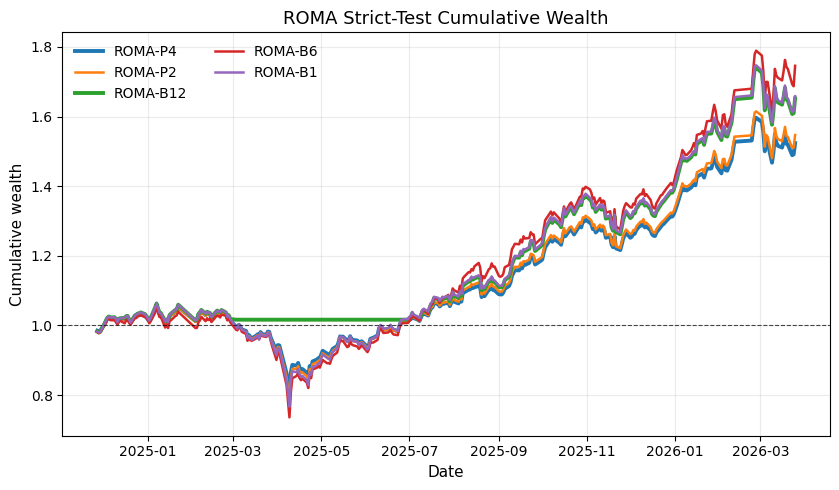

Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/aligned_allocation_backtest/run_20260625_025314/paper_figures/figure_6_1_roma_cumulative_wealth.png
Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/aligned_allocation_backtest/run_20260625_025314/paper_figures/figure_6_1_roma_cumulative_wealth.pdf


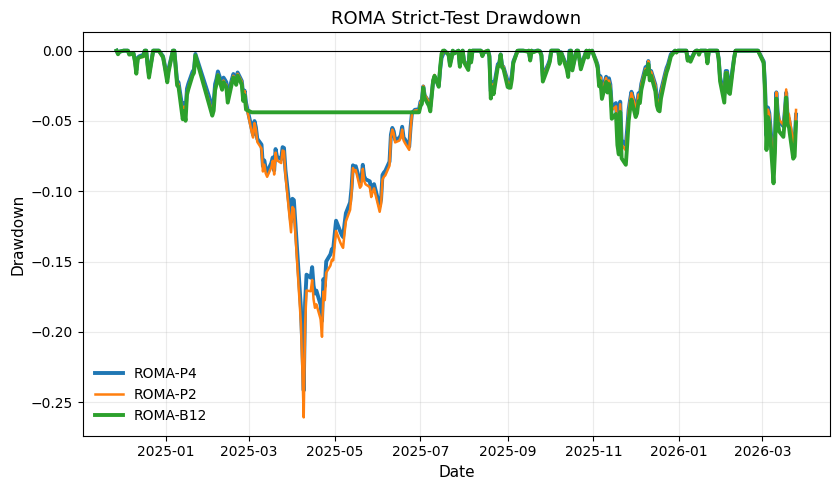

Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/aligned_allocation_backtest/run_20260625_025314/paper_figures/figure_6_2_roma_drawdown.png
Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/aligned_allocation_backtest/run_20260625_025314/paper_figures/figure_6_2_roma_drawdown.pdf

Exported plotted data:
/content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/aligned_allocation_backtest/run_20260625_025314/paper_figures/figure_6_1_roma_cumulative_wealth_data.csv
/content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/aligned_allocation_backtest/run_20260625_025314/paper_figures/figure_6_2_roma_drawdown_data.csv

Summary check:


,strategy,resolved_column,total_return_check,max_drawdown_check
0,ROMA-P4,ROMA_P4_balanced_regime_blend,0.524028,-0.241634
1,ROMA-P2,ROMA_P2_20d_only_return_seeking,0.546946,-0.260750
2,ROMA-B12,B12_ma_timing_equal_weight,0.652240,-0.094307
3,ROMA-B6,B6_00881_only,0.745921,-0.300012
4,ROMA-B1,B1_equal_weight_all_etfs,0.658435,-0.278465


Saved: /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/aligned_allocation_backtest/run_20260625_025314/paper_figures/figure_6_1_6_2_summary_check.csv


In [2]:
# =============================================================================
# Figure 6.1 and Figure 6.2 for Section 6.3 ROMA Baseline Performance
# Handles both long-format and wide-format roma_R2_all_returns.parquet files
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 0. Colab setup
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Google Drive mount skipped or failed.")
# =============================================================================
# 1. Configuration
# =============================================================================

RETURNS_PATH = Path(
    "/content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/"
    "aligned_allocation_backtest/run_20260625_025314/returns/"
    "roma_R2_all_returns.parquet"
)

OUT_DIR = Path(
    "/content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_TWETF/"
    "aligned_allocation_backtest/run_20260625_025314/paper_figures"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

STRICT_START = "2024-11-27"
STRICT_END = "2026-03-25"

FIG61_STRATEGIES = [
    "ROMA_P4_balanced_regime_blend",
    "ROMA_P2_20d_only_return_seeking",
    "B12_ma_timing_equal_weight",
    "B6_00881_only",
    "B1_equal_weight_all_etfs",
]

FIG62_STRATEGIES = [
    "ROMA_P4_balanced_regime_blend",
    "ROMA_P2_20d_only_return_seeking",
    "B12_ma_timing_equal_weight",
]

LABEL_MAP = {
    "ROMA_P4_balanced_regime_blend": "ROMA-P4",
    "ROMA_P2_20d_only_return_seeking": "ROMA-P2",
    "B12_ma_timing_equal_weight": "ROMA-B12",
    "B6_00881_only": "ROMA-B6",
    "B1_equal_weight_all_etfs": "ROMA-B1",
}


# =============================================================================
# 2. Load parquet and inspect structure
# =============================================================================

raw = pd.read_parquet(RETURNS_PATH)

print("Raw parquet loaded")
print("Shape:", raw.shape)
print("Columns:")
print(raw.columns.tolist())
print("\nHead:")
display(raw.head())


# =============================================================================
# 3. Convert to wide return matrix
# =============================================================================

def find_first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


def prepare_return_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """
    Converts the ROMA return parquet into a wide matrix:
        index = date
        columns = strategy names
        values = daily returns

    Works for both:
    1. Long format: date / policy_name / return column
    2. Wide format: date index with one strategy per column
    """

    df = df.copy()
    cols = df.columns.tolist()

    date_col = find_first_existing(
        cols,
        ["date", "Date", "datetime", "timestamp", "trade_date"]
    )

    policy_col = find_first_existing(
        cols,
        ["policy_name", "strategy", "strategy_name", "column", "asset", "name"]
    )

    return_col = find_first_existing(
        cols,
        [
            "daily_return",
            "return",
            "returns",
            "strategy_return",
            "portfolio_return",
            "net_return",
            "ret",
        ]
    )

    split_col = find_first_existing(
        cols,
        ["split", "sample", "period"]
    )

    # -------------------------------------------------------------------------
    # Case A: Long format
    # -------------------------------------------------------------------------
    if date_col is not None and policy_col is not None and return_col is not None:
        print("\nDetected long-format return table.")
        print("Date column:", date_col)
        print("Policy column:", policy_col)
        print("Return column:", return_col)
        if split_col is not None:
            print("Split column:", split_col)

        df[date_col] = pd.to_datetime(df[date_col])

        # Prefer strict_test_only if split column exists
        if split_col is not None:
            unique_splits = sorted(df[split_col].dropna().unique().tolist())
            print("Available splits:", unique_splits)

            if "strict_test_only" in unique_splits:
                df = df[df[split_col] == "strict_test_only"].copy()
                print("Filtered to split == strict_test_only")

        wide = (
            df.pivot_table(
                index=date_col,
                columns=policy_col,
                values=return_col,
                aggfunc="first"
            )
            .sort_index()
        )

        wide.index.name = "date"
        return wide

    # -------------------------------------------------------------------------
    # Case B: Wide format with date column
    # -------------------------------------------------------------------------
    if date_col is not None:
        print("\nDetected wide-format table with date column.")
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col).sort_index()
        numeric = df.select_dtypes(include=[np.number]).copy()
        numeric.index.name = "date"
        return numeric

    # -------------------------------------------------------------------------
    # Case C: Wide format with datetime index
    # -------------------------------------------------------------------------
    print("\nTrying wide-format table with existing index.")
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    numeric = df.select_dtypes(include=[np.number]).copy()
    numeric.index.name = "date"
    return numeric


returns_all = prepare_return_matrix(raw)

print("\nPrepared wide return matrix")
print("Shape:", returns_all.shape)
print("Date range:", returns_all.index.min(), "to", returns_all.index.max())
print("\nColumns containing P4, P2, B12, B6, or B1:")
print([c for c in returns_all.columns if any(k in str(c) for k in ["P4", "P2", "B12", "B6", "B1"])])


# =============================================================================
# 4. Filter strict-test period
# =============================================================================

returns_strict = returns_all.loc[STRICT_START:STRICT_END].copy()

if returns_strict.empty:
    raise ValueError(
        f"No rows found for strict-test period {STRICT_START} to {STRICT_END}."
    )

print("\nStrict-test return matrix")
print("Shape:", returns_strict.shape)
print("Date range:", returns_strict.index.min(), "to", returns_strict.index.max())


# =============================================================================
# 5. Resolve strategy columns
# =============================================================================

def resolve_columns(df: pd.DataFrame, requested_cols: list) -> list:
    resolved = []

    all_cols = [str(c) for c in df.columns]

    for requested in requested_cols:
        if requested in df.columns:
            resolved.append(requested)
            continue

        # Try exact match after string conversion
        exact_matches = [c for c in df.columns if str(c) == requested]
        if len(exact_matches) == 1:
            resolved.append(exact_matches[0])
            continue

        # Try with ROMA_ prefix
        prefixed = f"ROMA_{requested}"
        prefixed_matches = [c for c in df.columns if str(c) == prefixed]
        if len(prefixed_matches) == 1:
            resolved.append(prefixed_matches[0])
            continue

        # Try without ROMA_ prefix
        if requested.startswith("ROMA_"):
            unprefixed = requested.replace("ROMA_", "", 1)
            unprefixed_matches = [c for c in df.columns if str(c) == unprefixed]
            if len(unprefixed_matches) == 1:
                resolved.append(unprefixed_matches[0])
                continue

        # Substring fallback
        substring_matches = [
            c for c in df.columns
            if requested in str(c) or str(c) in requested
        ]

        if len(substring_matches) == 1:
            resolved.append(substring_matches[0])
            continue

        print("\nCould not resolve:", requested)
        print("Related available columns:")
        print([c for c in df.columns if any(k in str(c) for k in ["P4", "P2", "B12", "B6", "B1"])])
        raise ValueError(f"Could not resolve requested strategy column: {requested}")

    return resolved


fig61_cols = resolve_columns(returns_strict, FIG61_STRATEGIES)
fig62_cols = resolve_columns(returns_strict, FIG62_STRATEGIES)

print("\nFigure 6.1 columns:")
print(fig61_cols)

print("\nFigure 6.2 columns:")
print(fig62_cols)


# =============================================================================
# 6. Compute wealth and drawdown
# =============================================================================

def compute_wealth(r: pd.DataFrame) -> pd.DataFrame:
    return (1.0 + r.fillna(0.0)).cumprod()


def compute_drawdown(wealth: pd.DataFrame) -> pd.DataFrame:
    return wealth / wealth.cummax() - 1.0


# =============================================================================
# 7. Figure 6.1: Cumulative wealth
# =============================================================================

fig61_returns = returns_strict[fig61_cols].copy()

fig61_display_names = {
    resolved: LABEL_MAP.get(original, str(resolved))
    for original, resolved in zip(FIG61_STRATEGIES, fig61_cols)
}

fig61_wealth = compute_wealth(fig61_returns).rename(columns=fig61_display_names)

plt.figure(figsize=(8.5, 5.0))

for col in fig61_wealth.columns:
    lw = 2.8 if col in ["ROMA-P4", "ROMA-B12"] else 1.8
    plt.plot(fig61_wealth.index, fig61_wealth[col], label=col, linewidth=lw)

plt.axhline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.7)
plt.title("ROMA Strict-Test Cumulative Wealth", fontsize=13)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Cumulative wealth", fontsize=11)
plt.legend(frameon=False, ncol=2, fontsize=10)
plt.grid(True, alpha=0.25)
plt.tight_layout()

fig61_png = OUT_DIR / "figure_6_1_roma_cumulative_wealth.png"
fig61_pdf = OUT_DIR / "figure_6_1_roma_cumulative_wealth.pdf"

plt.savefig(fig61_png, dpi=300, bbox_inches="tight")
plt.savefig(fig61_pdf, bbox_inches="tight")
plt.show()

print("Saved:", fig61_png)
print("Saved:", fig61_pdf)


# =============================================================================
# 8. Figure 6.2: Drawdown
# =============================================================================

fig62_returns = returns_strict[fig62_cols].copy()

fig62_display_names = {
    resolved: LABEL_MAP.get(original, str(resolved))
    for original, resolved in zip(FIG62_STRATEGIES, fig62_cols)
}

fig62_wealth = compute_wealth(fig62_returns).rename(columns=fig62_display_names)
fig62_drawdown = compute_drawdown(fig62_wealth)

plt.figure(figsize=(8.5, 5.0))

for col in fig62_drawdown.columns:
    lw = 2.8 if col in ["ROMA-P4", "ROMA-B12"] else 1.8
    plt.plot(fig62_drawdown.index, fig62_drawdown[col], label=col, linewidth=lw)

plt.axhline(0.0, color="black", linewidth=0.8)
plt.title("ROMA Strict-Test Drawdown", fontsize=13)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Drawdown", fontsize=11)
plt.legend(frameon=False, fontsize=10)
plt.grid(True, alpha=0.25)
plt.tight_layout()

fig62_png = OUT_DIR / "figure_6_2_roma_drawdown.png"
fig62_pdf = OUT_DIR / "figure_6_2_roma_drawdown.pdf"

plt.savefig(fig62_png, dpi=300, bbox_inches="tight")
plt.savefig(fig62_pdf, bbox_inches="tight")
plt.show()

print("Saved:", fig62_png)
print("Saved:", fig62_pdf)


# =============================================================================
# 9. Export plotted data and quick checks
# =============================================================================

fig61_data_path = OUT_DIR / "figure_6_1_roma_cumulative_wealth_data.csv"
fig62_data_path = OUT_DIR / "figure_6_2_roma_drawdown_data.csv"

fig61_wealth.to_csv(fig61_data_path)
fig62_drawdown.to_csv(fig62_data_path)

print("\nExported plotted data:")
print(fig61_data_path)
print(fig62_data_path)

summary_rows = []

for original, resolved in zip(FIG61_STRATEGIES, fig61_cols):
    s = returns_strict[resolved].fillna(0.0)
    total_return = (1.0 + s).prod() - 1.0
    wealth_tmp = (1.0 + s).cumprod()
    max_drawdown = (wealth_tmp / wealth_tmp.cummax() - 1.0).min()

    summary_rows.append({
        "strategy": LABEL_MAP.get(original, original),
        "resolved_column": str(resolved),
        "total_return_check": total_return,
        "max_drawdown_check": max_drawdown,
    })

summary_check = pd.DataFrame(summary_rows)
summary_check_path = OUT_DIR / "figure_6_1_6_2_summary_check.csv"
summary_check.to_csv(summary_check_path, index=False)

print("\nSummary check:")
display(summary_check.round(6))
print("Saved:", summary_check_path)